# 07 - Cross-source sanity joins

Lightweight crosswalks across GTFS + Census + OSM + destination tables, with a named transit-desert output.

## Named output
**Tracts with zero (or very few) stops within X km** (X configurable below) - exported to `artifacts/tables/` and visualized in `artifacts/figures/`.

No full accessibility model here; keep that for pipeline `notebooks/03_accessibility_computation.ipynb`.

**Prior:** [`06_opportunities_and_destinations.ipynb`](06_opportunities_and_destinations.ipynb)

In [1]:
from __future__ import annotations

from datetime import date
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display
from shapely.geometry import box


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists():
            return d
    raise FileNotFoundError("Could not find configs/san_diego.yaml (cd to repo root).")


def latest_required(path_glob: str, base: Path) -> Path:
    files = sorted(base.glob(path_glob))
    if not files:
        raise FileNotFoundError(f"Missing required artifact: {path_glob}")
    return files[-1]


REPO_ROOT = find_repo_root()
with open(REPO_ROOT / "configs" / "defaults.yaml") as f:
    config = yaml.safe_load(f)
with open(REPO_ROOT / "configs" / "san_diego.yaml") as f:
    config.update(yaml.safe_load(f))

bbox = config["bbox"]
min_lon, min_lat, max_lon, max_lat = bbox

census_cfg = config.get("census", {})
state_fips = str(census_cfg.get("state_fips", config.get("state_fips", "06"))).zfill(2)
county_fips = str(census_cfg.get("county_fips", config.get("county_fips", "073"))).zfill(3)
acs_year = int(census_cfg.get("acs_year", 2023))

TODAY = date.today().isoformat()
ART_TABLES = REPO_ROOT / "artifacts" / "tables"
ART_FIG = REPO_ROOT / "artifacts" / "figures"
ART_TABLES.mkdir(parents=True, exist_ok=True)
ART_FIG.mkdir(parents=True, exist_ok=True)

# Transit-desert threshold for this EDA output
NEAR_STOP_KM = 0.5

print(f"REPO_ROOT={REPO_ROOT}")
print(f"bbox={bbox}")
print(f"NEAR_STOP_KM={NEAR_STOP_KM}")

REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
bbox=[-117.28, 32.53, -116.93, 33.11]
NEAR_STOP_KM=0.5


## Load latest EDA artifacts (04, 05, 06)

In [2]:
p_gtfs = latest_required("eda__tract_gtfs_service__*.csv", ART_TABLES)
p_walk = latest_required("eda__osm_tract_walk_edges__*.csv", ART_TABLES)
p_dest = latest_required("eda__tract_osm_destination_counts__*.csv", ART_TABLES)

gtfs = pd.read_csv(p_gtfs, dtype={"GEOID": str})
walk = pd.read_csv(p_walk, dtype={"GEOID": str})
dest = pd.read_csv(p_dest, dtype={"GEOID": str})

display(Markdown("### Source artifacts loaded"))
display(
    pd.DataFrame(
        [
            {"table": p_gtfs.name, "rows": len(gtfs), "cols": gtfs.shape[1]},
            {"table": p_walk.name, "rows": len(walk), "cols": walk.shape[1]},
            {"table": p_dest.name, "rows": len(dest), "cols": dest.shape[1]},
        ]
    )
)

### Source artifacts loaded

,table,rows,cols
0,eda__tract_gtfs_service__2026-03-29.csv,737,17
1,eda__osm_tract_walk_edges__2026-03-29.csv,737,11
2,eda__tract_osm_destination_counts__2026-03-29.csv,737,5


## Build tract base geometry and study-bbox flag

In [3]:
tiger_dir = REPO_ROOT / "data" / "raw" / "census" / f"tl_{acs_year}_{state_fips}_tract"
shp = tiger_dir / f"tl_{acs_year}_{state_fips}_tract.shp"
if not shp.exists():
    raise FileNotFoundError(f"Missing TIGER shapefile: {shp}")

tracts_all = gpd.read_file(shp)
tracts_sd = tracts_all[
    (tracts_all["STATEFP"].astype(str).str.zfill(2) == state_fips)
    & (tracts_all["COUNTYFP"].astype(str).str.zfill(3) == county_fips)
].copy()
tracts_sd["GEOID"] = tracts_sd["GEOID"].astype(str)

study_poly = box(min_lon, min_lat, max_lon, max_lat)
tracts_sd["intersects_study_bbox"] = tracts_sd.geometry.intersects(study_poly)

display(Markdown("### Tract geometry base"))
display(
    pd.DataFrame(
        [{"n_sd_tracts": len(tracts_sd), "n_intersects_bbox": int(tracts_sd["intersects_study_bbox"].sum())}]
    )
)

### Tract geometry base

,n_sd_tracts,n_intersects_bbox
0,737,571


## Cross-source join diagnostics

In [4]:
base = tracts_sd[["GEOID", "NAME", "intersects_study_bbox"]].drop_duplicates("GEOID")

j = base.merge(gtfs, on="GEOID", how="left", suffixes=("", "_gtfs"))
j = j.merge(walk[[c for c in walk.columns if c != "NAME"]], on="GEOID", how="left", suffixes=("", "_walk"))
j = j.merge(dest[[c for c in dest.columns if c != "intersects_study_bbox"]], on="GEOID", how="left")

diag_rows = []
for name, df in [("base", base), ("gtfs", gtfs), ("walk", walk), ("dest", dest), ("joined", j)]:
    diag_rows.append({"source": name, "n_rows": len(df), "n_unique_geoid": int(df["GEOID"].nunique())})

display(Markdown("### Row + GEOID diagnostics"))
display(pd.DataFrame(diag_rows))

for c in [
    "n_stops_in_bbox",
    "n_stops_mts",
    "n_stops_nctd",
    "dist_nearest_stop_m",
    "walk_edge_density_km_per_km2",
    "disadvantage_z",
    "poverty_rate",
]:
    if c in j.columns:
        j[c] = pd.to_numeric(j[c], errors="coerce")

for c in [c for c in j.columns if c.startswith("n_osm_")]:
    j[c] = pd.to_numeric(j[c], errors="coerce").fillna(0).astype(int)

p_diag = ART_TABLES / f"eda__cross_source_join_diagnostics__{TODAY}.csv"
pd.DataFrame(diag_rows).to_csv(p_diag, index=False)
print(f"Saved: {p_diag.relative_to(REPO_ROOT)}")

### Row + GEOID diagnostics

,source,n_rows,n_unique_geoid
0,base,737,737
1,gtfs,737,737
2,walk,737,737
3,dest,737,737
4,joined,737,737


Saved: artifacts\tables\eda__cross_source_join_diagnostics__2026-03-30.csv


## Named output: tracts with zero or very few stops within X km

In [5]:
if "dist_nearest_stop_m" not in j.columns or "n_stops_in_bbox" not in j.columns:
    raise ValueError("Joined table missing required GTFS fields: dist_nearest_stop_m and/or n_stops_in_bbox")

j["dist_nearest_stop_km"] = j["dist_nearest_stop_m"] / 1000.0
j["few_stops_within_x_km"] = (j["n_stops_in_bbox"].fillna(0) <= 1) & (
    j["dist_nearest_stop_km"].fillna(np.inf) > NEAR_STOP_KM
)
j["zero_stops_within_x_km"] = (j["n_stops_in_bbox"].fillna(0) == 0) & (
    j["dist_nearest_stop_km"].fillna(np.inf) > NEAR_STOP_KM
)

keep_cols = [
    "GEOID",
    "NAME",
    "intersects_study_bbox",
    "n_stops_in_bbox",
    "n_stops_mts",
    "n_stops_nctd",
    "dist_nearest_stop_m",
    "dist_nearest_stop_km",
    "few_stops_within_x_km",
    "zero_stops_within_x_km",
    "disadvantage_z",
    "poverty_rate",
]
keep_cols += [c for c in j.columns if c.startswith("n_osm_")]
keep_cols += [c for c in ["walk_edge_density_km_per_km2"] if c in j.columns]

named = j[[c for c in keep_cols if c in j.columns]].copy()
named = named.sort_values(
    ["zero_stops_within_x_km", "few_stops_within_x_km", "dist_nearest_stop_km"],
    ascending=[False, False, False],
)

x_tag = str(NEAR_STOP_KM).replace(".", "p")
p_named = ART_TABLES / f"eda__tracts_zero_or_few_stops_within_{x_tag}km__{TODAY}.csv"
named.to_csv(p_named, index=False)
print(f"Saved: {p_named.relative_to(REPO_ROOT)}")

summary = pd.DataFrame(
    [
        {"metric": "n_tracts_total", "value": len(named)},
        {"metric": "n_tracts_bbox_intersect", "value": int(named["intersects_study_bbox"].sum())},
        {"metric": "n_few_stops_within_x_km", "value": int(named["few_stops_within_x_km"].sum())},
        {"metric": "n_zero_stops_within_x_km", "value": int(named["zero_stops_within_x_km"].sum())},
        {"metric": "x_km_threshold", "value": NEAR_STOP_KM},
    ]
)

p_sum = ART_TABLES / f"eda__tracts_zero_or_few_stops_summary__{TODAY}.csv"
summary.to_csv(p_sum, index=False)
print(f"Saved: {p_sum.relative_to(REPO_ROOT)}")
display(summary)

Saved: artifacts\tables\eda__tracts_zero_or_few_stops_within_0p5km__2026-03-30.csv
Saved: artifacts\tables\eda__tracts_zero_or_few_stops_summary__2026-03-30.csv


,metric,value
0,n_tracts_total,737.0
1,n_tracts_bbox_intersect,571.0
2,n_few_stops_within_x_km,274.0
3,n_zero_stops_within_x_km,246.0
4,x_km_threshold,0.5


## Optional sanity slice for quick review

In [6]:
view_cols = [
    c
    for c in [
        "GEOID",
        "NAME",
        "intersects_study_bbox",
        "n_stops_in_bbox",
        "dist_nearest_stop_km",
        "few_stops_within_x_km",
        "zero_stops_within_x_km",
        "disadvantage_z",
        "poverty_rate",
        "walk_edge_density_km_per_km2",
        "n_osm_hospitals",
        "n_osm_groceries",
        "n_osm_schools",
    ]
    if c in named.columns
]

display(Markdown("### Top 25 candidate low-stop tracts"))
display(named[view_cols].head(25))

### Top 25 candidate low-stop tracts

,GEOID,NAME,intersects_study_bbox,n_stops_in_bbox,dist_nearest_stop_km,few_stops_within_x_km,zero_stops_within_x_km,disadvantage_z,poverty_rate,walk_edge_density_km_per_km2,n_osm_hospitals,n_osm_groceries,n_osm_schools
146,06073021002,210.02,False,0,64.533440,True,True,-0.203768,0.035779,0.0,0,0,0
189,06073021001,210.01,False,0,62.168675,True,True,0.402285,0.060363,0.0,0,0,0
195,06073021102,211.02,False,0,56.522869,True,True,1.510120,0.323331,0.0,0,0,0
318,06073019001,190.01,False,0,37.554419,True,True,-0.161063,0.078960,0.0,0,0,0
183,06073021101,211.01,False,0,37.343288,True,True,0.700422,0.185942,0.0,0,0,0
502,06073018903,189.03,False,0,31.932152,True,True,1.212980,0.310534,0.0,0,0,0
400,06073018700,187,False,0,31.216090,True,True,0.044287,0.049925,0.0,0,0,0
674,06073019002,190.02,False,0,30.987287,True,True,-0.258968,0.075956,0.0,0,0,0
466,06073020902,209.02,False,0,30.889827,True,True,-0.388033,0.033304,0.0,0,0,0
489,06073018904,189.04,False,0,30.174908,True,True,0.668173,0.167406,0.0,0,0,0


## Figures

C:\Users\sardo\AppData\Local\Temp\ipykernel_30856\957546954.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")


Saved: artifacts\figures\eda__tracts_zero_or_few_stops_within_0p5km__2026-03-30.png
Saved: artifacts\figures\eda__nearest_stop_distance_hist__2026-03-30.png


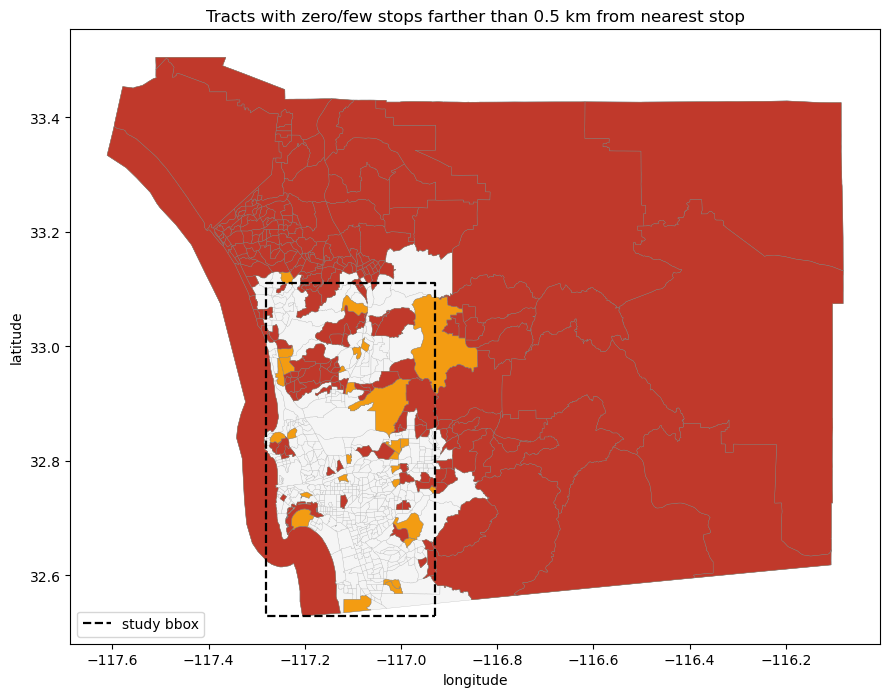

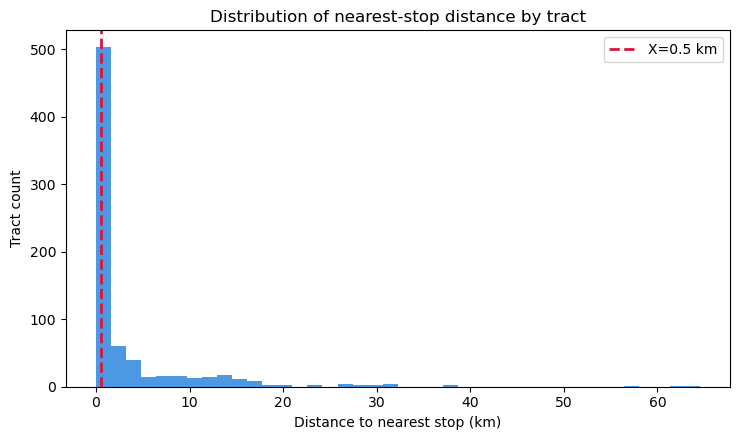

In [7]:
plot_gdf = tracts_sd.merge(
    named[["GEOID", "zero_stops_within_x_km", "few_stops_within_x_km", "dist_nearest_stop_km"]],
    on="GEOID",
    how="left",
)

fig, ax = plt.subplots(figsize=(9, 9))
plot_gdf.plot(ax=ax, color="whitesmoke", edgecolor="0.7", linewidth=0.2)
plot_gdf[plot_gdf["few_stops_within_x_km"] == True].plot(
    ax=ax, color="#f39c12", edgecolor="0.5", linewidth=0.3, label="few stops farther than X km"
)
plot_gdf[plot_gdf["zero_stops_within_x_km"] == True].plot(
    ax=ax, color="#c0392b", edgecolor="0.5", linewidth=0.3, label="zero stops farther than X km"
)

bbox_gdf = gpd.GeoDataFrame(geometry=[study_poly], crs="EPSG:4326")
bbox_gdf.boundary.plot(ax=ax, color="black", linestyle="--", linewidth=1.6, label="study bbox")

ax.set_title(f"Tracts with zero/few stops farther than {NEAR_STOP_KM} km from nearest stop")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="lower left")
plt.tight_layout()

x_tag = str(NEAR_STOP_KM).replace(".", "p")
fp1 = ART_FIG / f"eda__tracts_zero_or_few_stops_within_{x_tag}km__{TODAY}.png"
fig.savefig(fp1, dpi=200, bbox_inches="tight")
print(f"Saved: {fp1.relative_to(REPO_ROOT)}")

if "dist_nearest_stop_km" in named.columns:
    fig2, ax2 = plt.subplots(figsize=(7.5, 4.5))
    vals = named["dist_nearest_stop_km"].replace([np.inf, -np.inf], np.nan).dropna()
    ax2.hist(vals, bins=40, color="#2e86de", alpha=0.85)
    ax2.axvline(NEAR_STOP_KM, color="crimson", linestyle="--", linewidth=2, label=f"X={NEAR_STOP_KM} km")
    ax2.set_title("Distribution of nearest-stop distance by tract")
    ax2.set_xlabel("Distance to nearest stop (km)")
    ax2.set_ylabel("Tract count")
    ax2.legend()
    plt.tight_layout()

    fp2 = ART_FIG / f"eda__nearest_stop_distance_hist__{TODAY}.png"
    fig2.savefig(fp2, dpi=200, bbox_inches="tight")
    print(f"Saved: {fp2.relative_to(REPO_ROOT)}")